# Imports

In [1]:
from pathlib import Path

from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import numpy as np
import matplotlib.pyplot as plt

from starships import retrieval
from starships.plotting_fcts import get_plot_labels
import starships.retrieval_utils as ru
import starships.planet_obs as pl_obs

from starships import petitradtrans_utils

petitradtrans_utils.log.setLevel('INFO')
pl_obs.log.setLevel("WARNING")

# Loading the retrieval

First we need to point to the corresponding `yaml` file for the run we want to analyze. To ensure we are using the parameters provided when the retrieval was launched, and not a potentially modified version, it may be best to point to the copy created by starships when the run was launched.

In [2]:
# Provide the correct path to the where the retrieval yaml files are saved
retrieval_param_outdir = Path.home() / 'scratch/temp_yaml_files/'

In [3]:
# Use this to list the yaml files from the most recent
!ls -tl $retrieval_param_outdir

total 470
-rw-r-----. 1 mathisb mathisb 23041 Feb 24 20:46 trappist1b_1771983966.yaml
-rw-r-----. 1 mathisb mathisb 23042 Feb 24 11:50 trappist1b_1771951806.yaml
-rw-r-----. 1 mathisb mathisb 23425 Feb 24 10:30 trappist1b_1771947049.yaml
-rw-r-----. 1 mathisb mathisb 23427 Feb 24 10:24 trappist1b_1771946674.yaml
-rw-r-----. 1 mathisb mathisb 23544 Feb 18 11:20 trappist1b_1771431615.yaml
-rw-r-----. 1 mathisb mathisb 23537 Feb 17 14:12 trappist1b_1771355563.yaml
-rw-r-----. 1 mathisb mathisb 23539 Feb 17 13:27 trappist1b_1771352828.yaml
-rw-r-----. 1 mathisb mathisb 23544 Feb 17 12:29 trappist1b_1771349371.yaml
-rw-r-----. 1 mathisb mathisb 23924 Feb 17 11:08 trappist1b_1771344526.yaml
-rw-r-----. 1 mathisb mathisb 23876 Feb 16 17:00 trappist1b_1771279221.yaml


In [4]:
# Choose the yaml file of the retrieval you want to analyze
yaml_file_in = retrieval_param_outdir / 'trappist1b_1771983966.yaml'

Alternatively, we can directly provide a path to any `yaml` file.

In [5]:
# yaml_file_in = Path.home() / Path('VSCodeProjects/starships_analysis/WASP-33b/retrieval_inputs_wasp33.yaml')

With the `yaml` file specified, we can now load in the relevant parameters and info for the retrieval run.

In [6]:
retrieval.setup_retrieval(yaml_file_in)

INFO:starships.retrieval:spectrophotometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:photometric_data is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:linelist_names is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:reg_fixed_params is None. Setting it to an empty dictionary instead.
INFO:starships.retrieval:No walker file out name given. Setting it to walker_steps_greenhouse-gases_v2.h5
INFO:starships.retrieval:instrum = ['nirps_he']
INFO:starships.retrieval:high_res_path = /home/mathisb/scratch/HRS_reductions/NIRPS/TRAPPIST-1b/2024-07-05/v001
INFO:starships.retrieval:high_res_file_stem_list = ['retrieval_input_1-pc_mask_wings97']
INFO:starships.retrieval:spectrophotometric_data = {}
INFO:starships.retrieval:photometric_data = {}
INFO:starships.retrieval:retrieval_type = HRR
INFO:starships.retrieval:white_light = False
INFO:starships.retrieval:chemical_equilibrium = False
INFO:starships.ret

{'instrum': ['nirps_he'],
 'high_res_path': PosixPath('/home/mathisb/scratch/HRS_reductions/NIRPS/TRAPPIST-1b/2024-07-05/v001'),
 'high_res_file_stem_list': ['retrieval_input_1-pc_mask_wings97'],
 'spectrophotometric_data': {},
 'photometric_data': {},
 'retrieval_type': 'HRR',
 'white_light': False,
 'chemical_equilibrium': False,
 'dissociation': False,
 'kind_temp': 'iso',
 'run_name': 'greenhouse-gases_v2',
 'walker_file_out': PosixPath('walker_steps_greenhouse-gases_v2.h5'),
 'walker_file_in': PosixPath('walker_steps_greenhouse-gases_v2_combined.h5'),
 'init_mode': 'from_burnin',
 'n_cpu': 1,
 'n_walkers': 8,
 'n_walkers_per_cpu': 8,
 'line_opacities': ['H2O', 'CO2', 'CH4'],
 'continuum_opacities': [],
 'other_species': [],
 'species_in_prior': [],
 'remove_mol_high': [],
 'remove_mol_low': [],
 'pl_name': 'TRAPPIST-1 b',
 'base_dir': PosixPath('None'),
 'star_spectrum': None,
 'slurm_array_behaviour': None,
 'n_steps_burnin': 300,
 'n_steps_sampling': 2000,
 'walker_path': PosixP

We then get the plot labels for the retrieved parameters, the default walker file path as defined in the `yaml` file, and check the default walker file name. If the default walker file name does not point to the correct file (or to any valid file at all), we can provide the correct file manually.

In [7]:
# Get labels
labels = get_plot_labels(params=retrieval.params_prior)

# Get walker output path
walker_path = retrieval.walker_path

print('Default retrieval walker file:', retrieval.walker_file_out)

Default retrieval walker file: walker_steps_greenhouse-gases_v2.h5


The retrieval `walker_file` can be changed as long as it has the same parameters as in the `yaml` file provided earlier.

In [8]:
# Show latest 50 (or change to any number you would like) walker files in the walker_path directory
# !ls -t1 $walker_path | head -50

## Read the walker file

We can first read the walker file and store information about the parameter values at each step in the `chains` array. When using `read_walkers_file`, the steps will be ordered in the same way they happened during the retrieval. It is possible to discard a specified number of initial steps by using the `discard` argument.

STARSHIPS will notify whether all planned walker steps were completed or not; incomplete walker steps means either the retrieval was manually cancelled before it reached its set number of steps from the `yaml`, or ran out of time (if run on a cluster with a job scheduling system, for example).

In [9]:
# We can provide a walker file different from the default one from the yaml if we want
# walker_file = Path('walker_steps_emission_LRR_wfc3_spitzer_modif_disso_32470473_burnin.h5')

# But generally we simply want to use the yaml's default walker file
walker_file = retrieval.walker_file_out

print('walker file:', walker_file)
chains = ru.read_walkers_file(walker_path / walker_file, discard=0)

walker file: walker_steps_greenhouse-gases_v2.h5


INFO:starships.retrieval_utils:Steps in walkers file are all completed


The chains array has the shape (n_steps, n_walkers, n_parameters)

In [10]:
chains.shape

(2000, 160, 6)

In [11]:
# Review the parameter plotting labels, can edit these if you like (for clarity or any other reason)
labels

['$\\log_{10}$ H$_2$O',
 'CH4',
 '$\\log_{10}$ CO$_2$',
 'T_eq',
 '$K_{\\rm P}$',
 '$v_{\\rm rad}$']

# First plots

## Walker steps

The first thing we might want to look at is the progress of walkers for each parameter. The central panel will show the evolution of parameter values for all chains as a function of step number. The rightmost panel will show the distribution of those parameter values.

This plot is a good diagnostic of convergence for the various parameters: most walkers should converge to similar values, and this behaviour should be visible in the initial steps (not as much if a relatively long burn-in was used). On the other hand, for parameters with little convergence or constraints, the chain plots will look very noisy or messy, with no clear behavior, and the distribution plots will be very wide or even flat.

$\log_{10}$ H$_2$O: Maximum=-8.636847235142314, Error=[-0.67439185  6.92590603], HDI(68.00%)=[-9.31123908 -1.7109412 ]
CH4: Maximum=-2.244651980639839, Error=[-2.96483169  1.82461422], HDI(68.00%)=[-5.20948367 -0.42003776]
$\log_{10}$ CO$_2$: Maximum=-10.128468404909285, Error=[-1.75822223  5.45199303], HDI(68.00%)=[-11.88669063  -4.67647537]
T_eq: Maximum=533.9225444887634, Error=[-214.09772066   66.05487255], HDI(68.00%)=[319.82482383 599.97741704]
$K_{\rm P}$: Maximum=51.23317833698476, Error=[-25.00570133  30.23502202], HDI(68.00%)=[26.22747701 81.46820036]
$v_{\rm rad}$: Maximum=5.180778143815201, Error=[-2.49459051  2.2429544 ], HDI(68.00%)=[2.68618763 7.42373255]


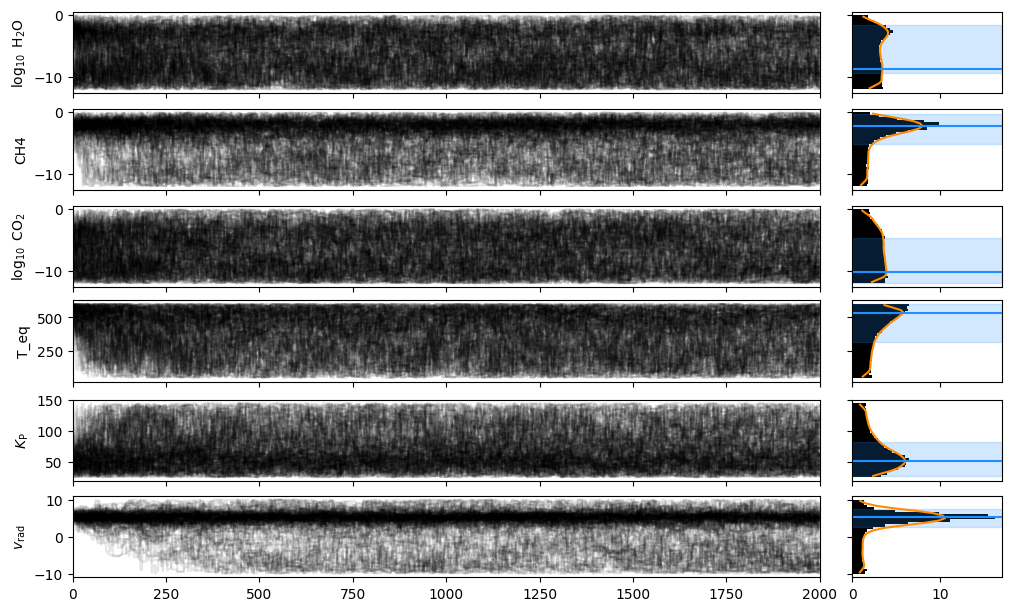

In [12]:
maxs, errors = ru.find_dist_maxs(chains, labels, bin_size=6, print_latex_style=False, alpha_plot=0.1)

Computing mean and spread/uncertainty statistics on the distributions.

## Corner plot

The corner plot is one of the most popular ways to display and analyze a retrieval's output. Density plots of the distributions of walkers are plotted for every pair of parameters, showing the covariance of parameters. This is a great tool to identify or confirm any correlation or degeneracy between parameters.

At the top of each columns, the marginalized posterior distribution for each parameter is plotted, along with their mean and spread. Note that those statistics are definitely more reliable and meaningful for Gaussian distributions.

Optionally, it is possible to restrain the corner plot to only a subset of parameters by first taking an appropriate subset of `chains` and `labels` and then going through with making the plots.

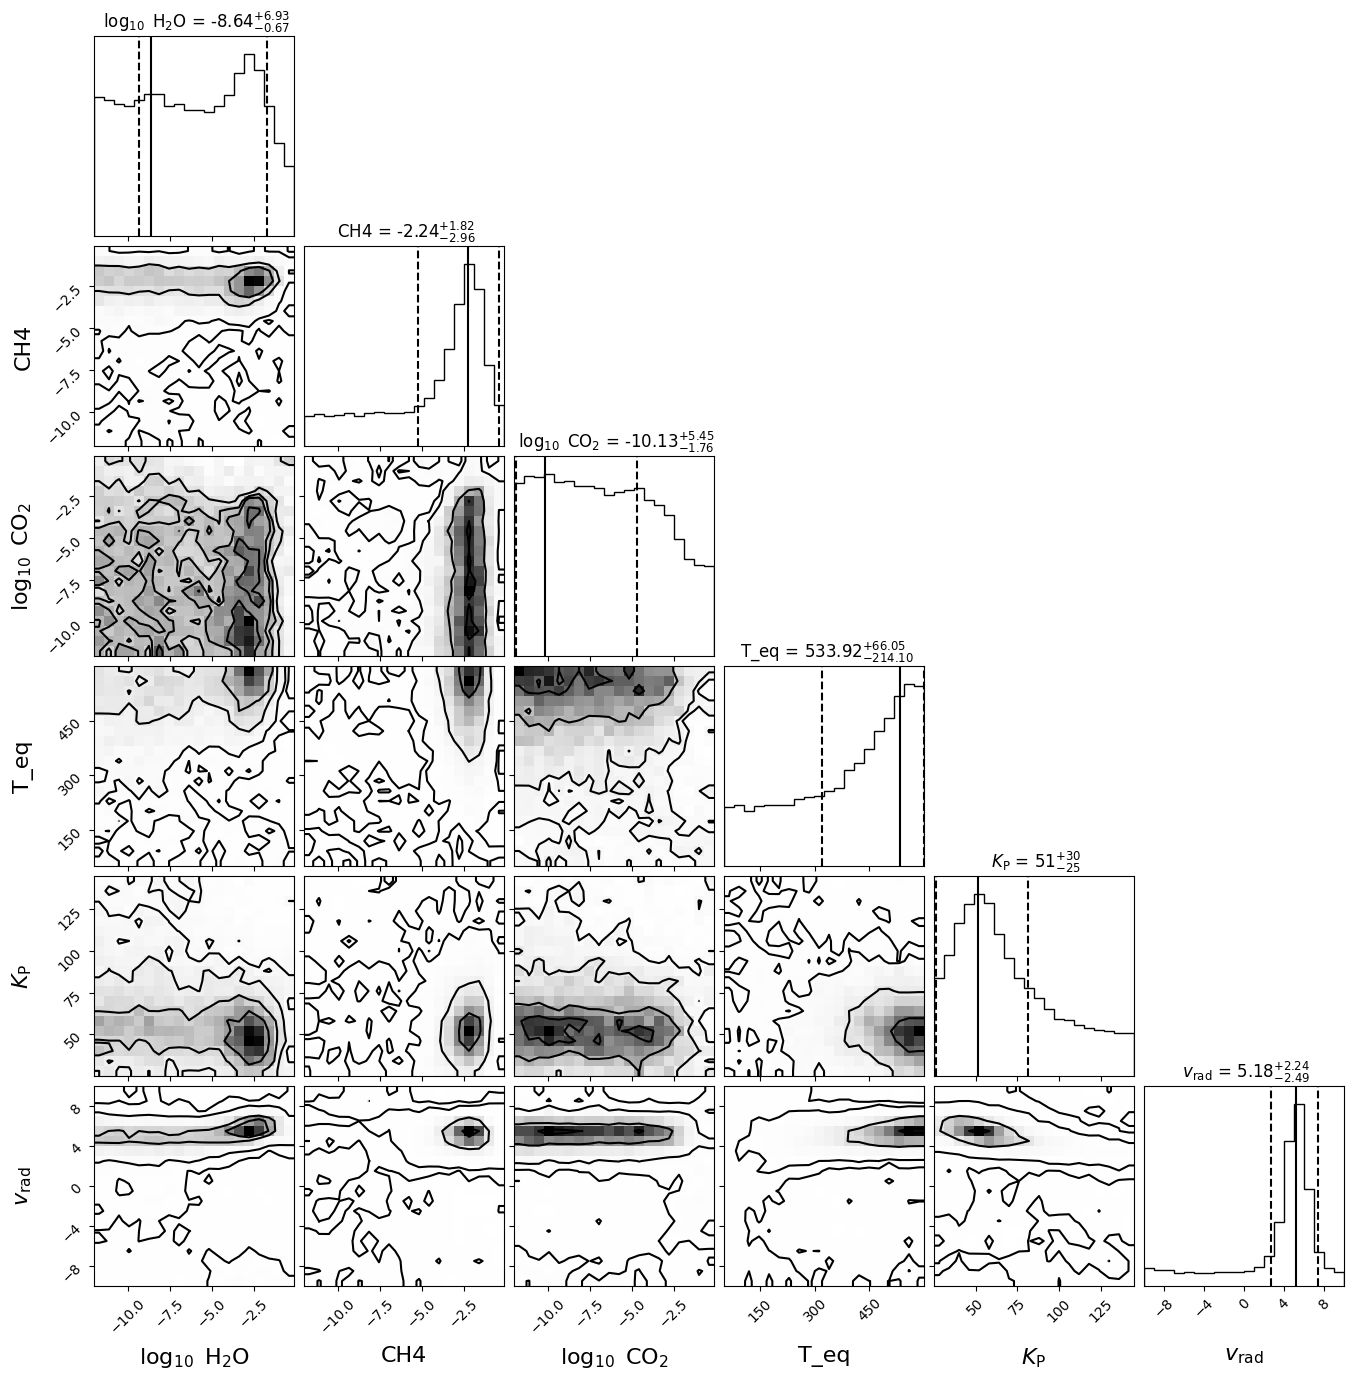

In [13]:
fig, flat_samples = ru.plot_corner(chains, labels, param_no_zero=4, maxs=maxs, errors=errors, plot_datapoints=False)

In [24]:
# Optionally, save the figure
# The default filename here uses the retrieval run name and the number of walker steps
# However, feel free to use any file name you like

# path_fig = Path.home() / 'nirps/retrievals/plots/WASP-80b'
# n_steps = str(chains.shape[0])
# fig.savefig(path_fig / f'{walker_file.name[:-3]}_{n_steps}_steps_corner_plot.pdf')

# Further analysis

Before continuing with a few extra analysis steps, we will load information from the walker file again, but this time we will also get the log likelihood at each step. Aditionnally, we will order the sample by log L (best/highest log L will be last). Again, a number of initial steps may be discarded using the `discard` argument.

In [31]:
# Get the posterior distribution ordered by their logl value (last value is the highest logl)
output = ru.read_walker_prob(walker_path/walker_file, tol=8, discard=2)

ord_pos, ord_logl, autocorr = output

## Verify the logl for each parameters
** This is especially useful if you want to do some analysis on burnin results

The log L distributions for each parameter can also be used to assess whether the retrieval is converging properly, i.e. finding a true maximum in log L.

Based on the log L scatter plot (see below):
- For burnins, are there 2 clear blobs separated vertically (in logl value)? 
- Is there an actual maximum?
- Are some walker stuck in a secondary maximum (if so, we might remove them)
- Do you want to restrain the parameters to a subsample for later use? Like to generate the spectra.

In [32]:
from starships.plotting_fcts import scatterplot_logl

In [33]:
print('Median logl value:', np.median(ord_logl))

Median logl value: 103366.64170286657


In [34]:
prior_keys = list(retrieval.params_prior.keys())

In [35]:
# Make a selection of the walker if wanted

# On the logl (Set it to -np.inf if not used)
cond = ord_logl > -np.inf

# and/or any other conditions

ord_pos_sub = ord_pos[cond]
ord_logl_sub = ord_logl[cond]

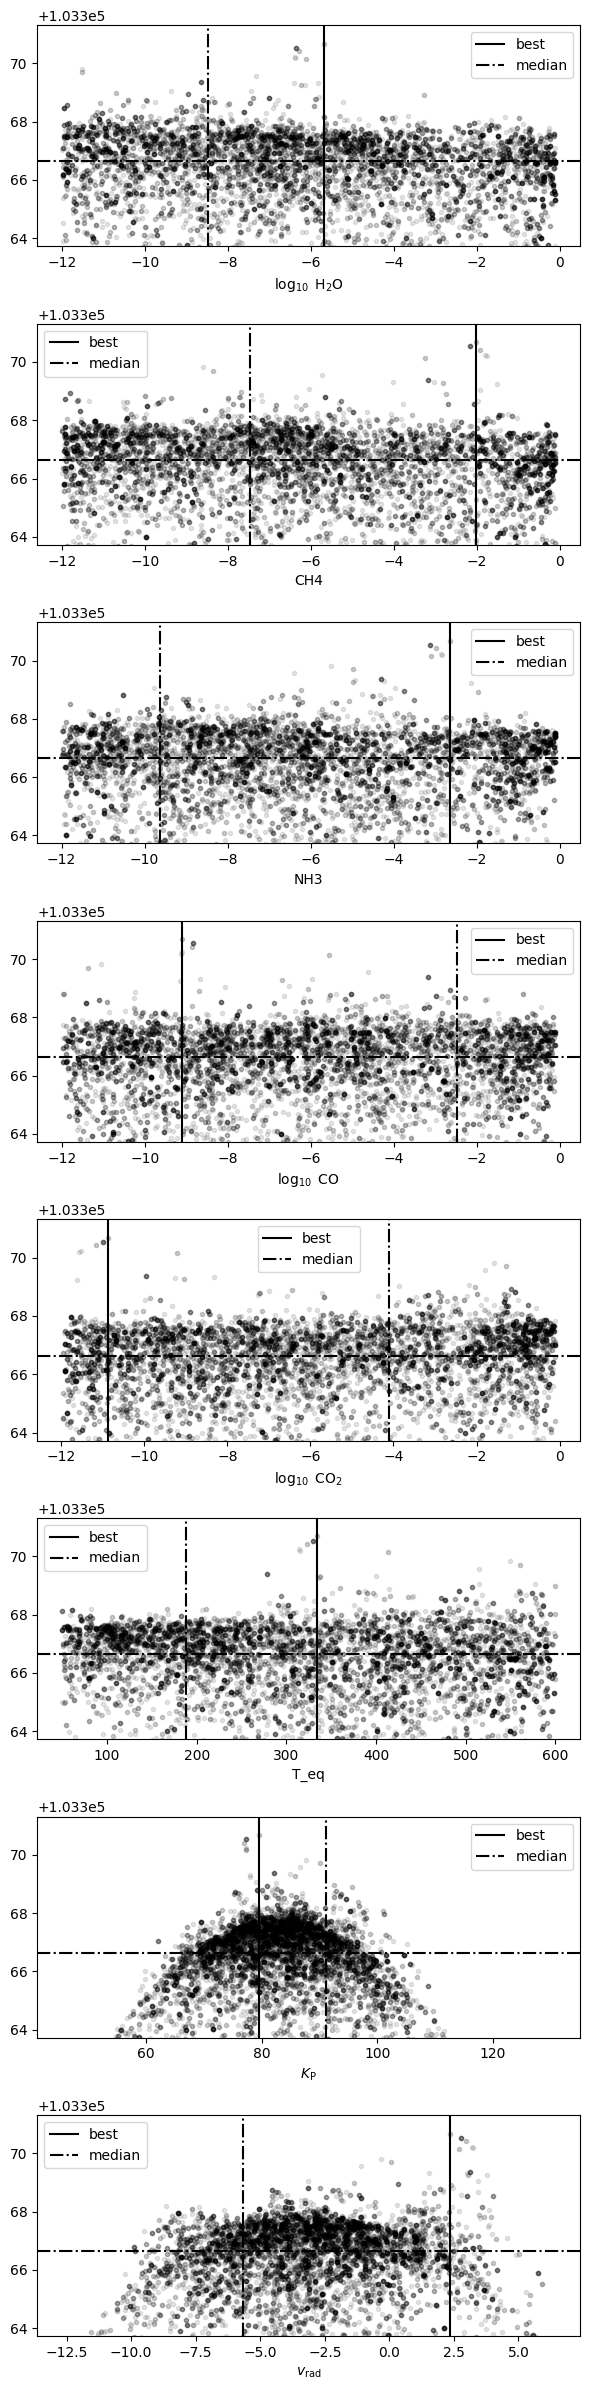

In [36]:
fig, ax = scatterplot_logl(ord_pos, ord_logl, n_max_pts=10000, tight_ylim=True,
                           alpha=0.1, color='k', ylabels=labels)

# Comment/uncomment the following lines to plot the sub_samples
# _ = scatterplot_logl(ord_pos_sub, ord_logl_sub, n_max_pts=10000, tight_ylim=True,
#                            alpha=0.3, color='darkgreen', ylabels=labels, ax=ax)

You can also remake the corner plot and walker steps plot (this time, ordered by increasing log likelihood) for the subsample if you want.

$\log_{10}$ H$_2$O: Maximum=-6.743440188481008, Error=[-4.97179019  2.74115818], HDI(68.00%)=[-11.71523038  -4.00228201]
CH4: Maximum=-6.491182244468418, Error=[-5.46233394  2.36859624], HDI(68.00%)=[-11.95351618  -4.122586  ]
NH3: Maximum=-6.671718825384531, Error=[-5.15217528  2.68763139], HDI(68.00%)=[-11.82389411  -3.98408743]
$\log_{10}$ CO: Maximum=-9.188978369666756, Error=[-2.49076038  5.44621576], HDI(68.00%)=[-11.67973875  -3.74276261]
$\log_{10}$ CO$_2$: Maximum=-7.827873147560604, Error=[-0.33840103  7.72625656], HDI(68.00%)=[-8.16627418 -0.10161659]
T_eq: Maximum=227.71875657819407, Error=[-131.15395283  232.43808199], HDI(68.00%)=[ 96.56480375 460.15683857]
$K_{\rm P}$: Maximum=82.77989363489999, Error=[-10.99868124   9.83596571], HDI(68.00%)=[71.7812124  92.61585935]
$v_{\rm rad}$: Maximum=-3.2152370770147334, Error=[-3.05604635  3.439791  ], HDI(68.00%)=[-6.27128343  0.22455393]


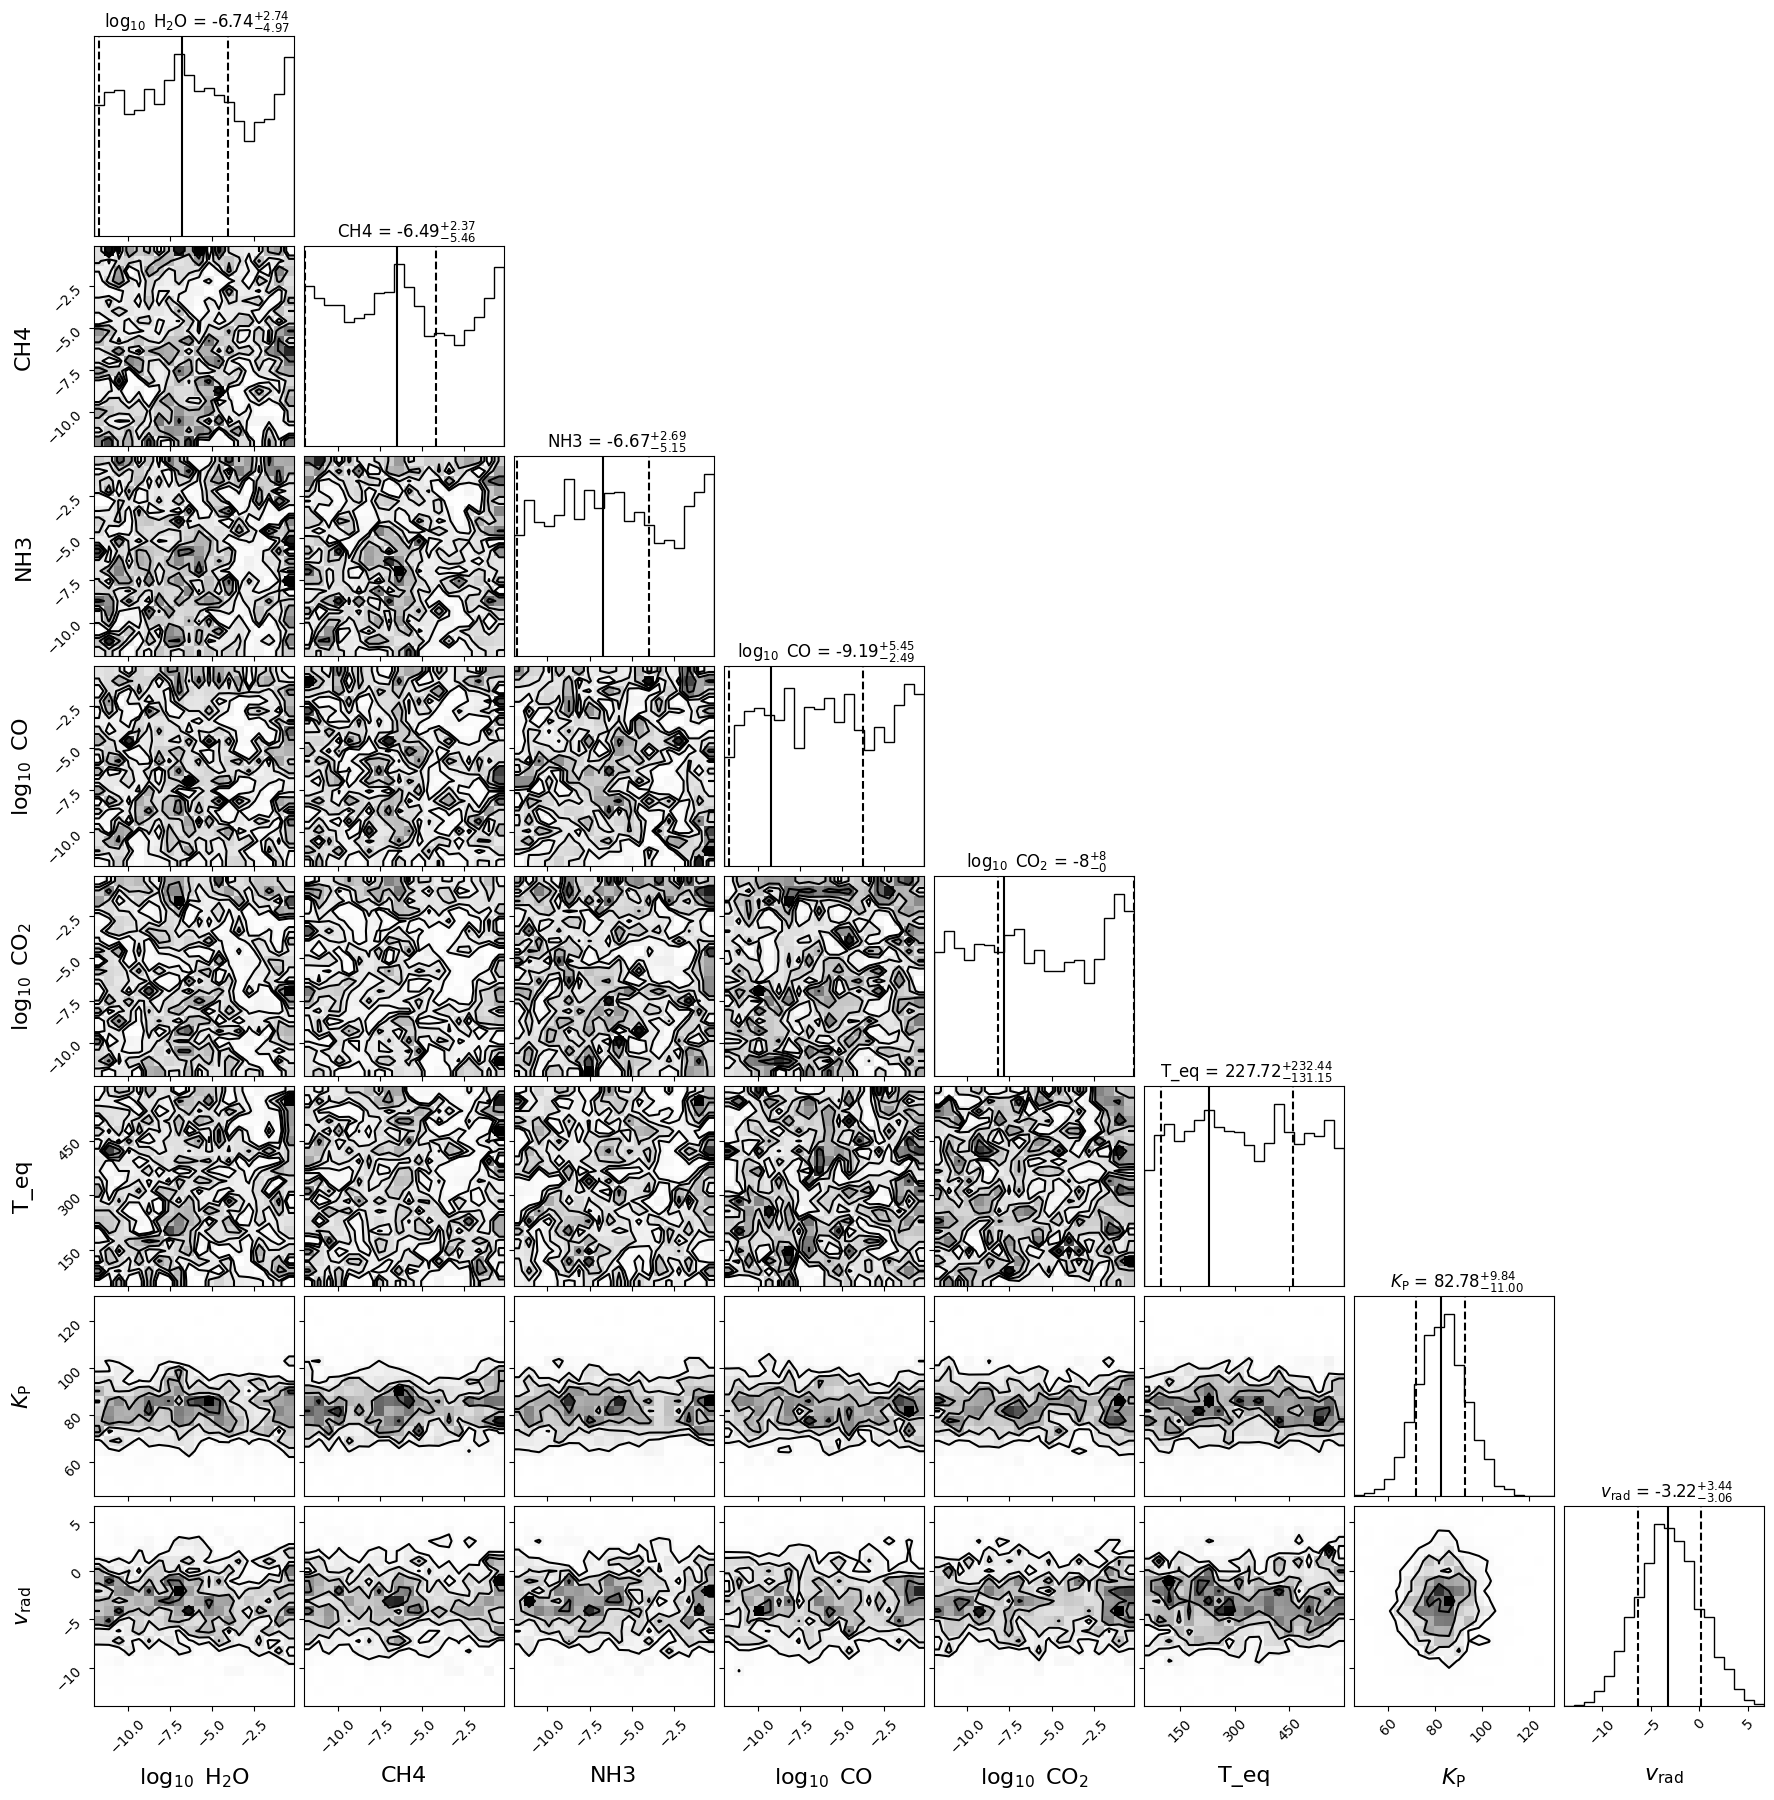

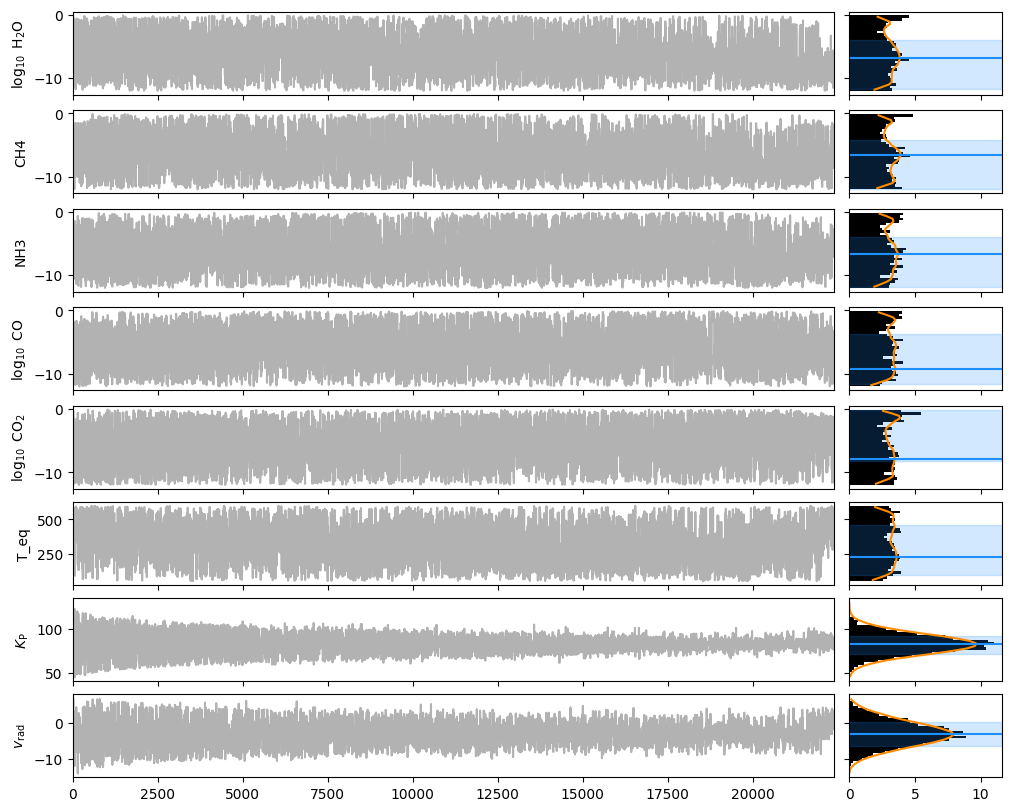

In [37]:
fig, flat_samples = ru.plot_corner(ord_pos_sub[:, None, :], labels, param_no_zero=4, plot_datapoints=False)

# Explore confidence intervals

Here we present a few tools to look at posterior statistics for the temperature-pressure and abundance profiles.

## Abundances and TP profiles

First we load in useful functions from starships to draw samples for these profiles, and plot them.

In [38]:
from starships.retrieval_utils import draw_profiles_form_sample, get_stats_from_profile

In [39]:
from starships.plotting_fcts import plot_p_profile_sample, plot_tp_sample

### Choose which sample to use
This can be a subsample defined by chosen conditions earlier.

In [40]:
# flatten_sample = flat_samples
# flatten_sample = chains.reshape((-1, chains.shape[-1]))
flatten_sample = ord_pos_sub

In [41]:
from starships.petitradtrans_utils import gen_abundances

In [42]:
# Definitions for a few utility functions for getting profile samples from our walkers
def get_tp_profile(params, idx_region=0):
    
    theta_dict = retrieval.unpack_theta(params)[idx_region]
    return theta_dict['pressures'], theta_dict['temperatures']


def get_mol_profile(params, idx_region=0):
    
    theta_dict = retrieval.unpack_theta(params)[idx_region]
    
    species = retrieval.line_opacities + retrieval.continuum_opacities + retrieval.other_species
    # Compute the abundances (and add species that need to be included if not fitted)
    abundances, MMW, VMR = gen_abundances(species, [theta_dict[key] for key in species],
                                     theta_dict['pressures'], theta_dict['temperatures'],
                                     verbose=False, vmrh2he=[0.85, 0.15],
                                     dissociation=retrieval.dissociation, plot=False)
    
    return VMR

In [43]:
# Combined list of all chemical species included in the retrieval
all_species = retrieval.line_opacities + retrieval.continuum_opacities + retrieval.other_species

In [44]:
# And now we actually draw the random sample profiles (here, 500; feel free to adjust this number)
profile_samples, pressures = draw_profiles_form_sample(500, flatten_sample, 
                                                       list_mols=all_species,
                                                       get_mol_profile=get_mol_profile, 
                                                       get_tp_from_param=get_tp_profile)

# Add a check to make sure the values are reasonnable
profile_stats = {key: get_stats_from_profile(val, log_scale=True)
                 for key, val in profile_samples.items()
                 if key != 'temperature'}
for key, val in profile_samples.items():
    if key != 'temperature':
        profile_samples[key] = np.clip(profile_samples[key], 1e-20, 1.)
    else:
        profile_samples[key] = np.clip(profile_samples[key], 0., 10000.)

`profile_samples` contains samples for all the species that the model uses, and also the pressure-temperature profile.

### Example profiles drawn from the sample

The shape of the profiles will depend on what was specified in the retrievals. For example, if the temperature profile was set to `isothermal`, then all profiles will be constant with pressure/altitude; if `Guillot` or another non-isothermal profile was used, we will get profiles that vary with pressure.

Abundance profiles will be constant with pressure by default in free chemistry retrievals.

Text(0.5, 0, 'Abundance')

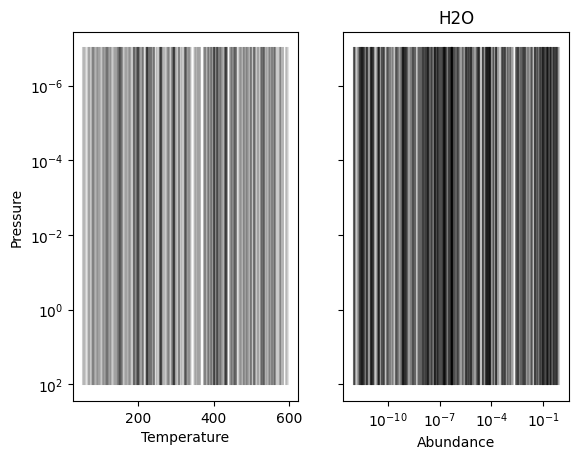

In [45]:
mol_name = 'H2O'

fig, ax = plt.subplots(1, 2, sharey=True)
ax[0].semilogy(profile_samples['temperature'].T, pressures, "k", alpha=0.1)
ax[0].invert_yaxis()

ax[1].loglog(profile_samples[mol_name].T, pressures, "k", alpha=0.2)
ax[1].set_title(mol_name)

ax[0].set_ylabel('Pressure')
ax[0].set_xlabel('Temperature')
ax[1].set_xlabel('Abundance')

### Statistics from these samples (median, 1-sigma, 2-sigma)

In [46]:
# Get statistics. Done in logspace for molecules, but not for temperature
profile_stats = {key: get_stats_from_profile(val, log_scale=True)
                 for key, val in profile_samples.items()
                 if key != 'temperature'}
profile_stats['temperature'] = get_stats_from_profile(profile_samples['temperature'])

### TP profiles statistics

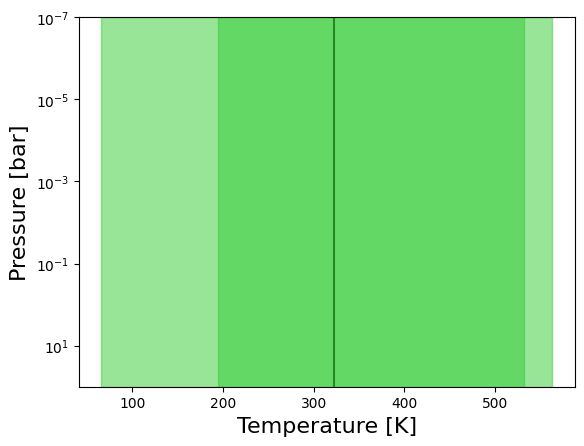

In [47]:
fig1, ax = plot_tp_sample(pressures, profile_stats['temperature'], p_range=(1e-10, 1e2))

### Abundance profiles statistics

This is especially useful visualization for retrievals where certain species are expected to vary significantly with altitude/pressure (e.g. H2O/OH in hot atmospheres).

Text(0.5, 0, 'Volume Mixing Ratio')

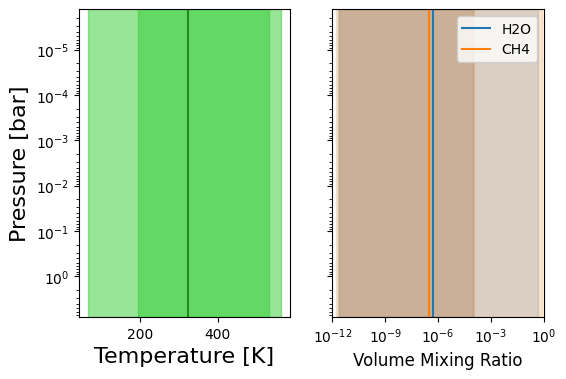

In [48]:
# Feel free to include more species form the retrieval
# and to add more sublots and separate species into groups for a good visualization
# For example, plot together two species for which the abundances are correlated

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(6, 4))

plot_tp_sample(pressures, profile_stats['temperature'], ax=ax[0])

for mol_name in ['H2O', 'CH4']:
    plot_p_profile_sample(pressures, profile_stats[mol_name], ax=ax[1], label=mol_name)
ax[1].set_xscale('log')
ax[1].set_xlim(1e-12, 1e0)
ax[1].legend()

ax[1].set_xlabel('Volume Mixing Ratio', fontsize='large')

# --- petitRADTRANS required past this point ---

All the remaining sections of the notebook require petitRADTRANS to compute models, so they were moved here to the end for reference purposes. They are also less commented.

### You can also overplot what is expected from chemical equilibrium

The plots in this subsection are from a completely different retrieval.

In [37]:
from petitRADTRANS.poor_mans_nonequ_chem import interpol_abundances
from starships.petitradtrans_utils import mass_frac_2_vmr

In [38]:
c_to_o = .95
Fe_to_H = None

# Compute Fe/H if Fe is available
if Fe_to_H is None and 'Fe' in profile_samples:
    pro_val = list(profile_samples.values())
    list_species=profile_samples.keys()
    Fe_profiles = ru.get_atom_abundance('Fe', pro_val, list_species=list_species)
    H_profiles = ru.get_atom_abundance('H', pro_val, list_species=list_species)
    # log10 VMR_Fe / VMR_H = -4.46 (=12. - 7.54)  (solar protosolar metallicity form Asplund 2009 table 5)
    FeHs = np.log10(Fe_profiles / H_profiles) - (-4.46)
else:
    if Fe_to_H is None:
        Fe_to_H = 0.
    FeHs = np.full_like(pressures, Fe_to_H)
    FeHs = np.broadcast_to(FeHs, profile_samples['temperature'].shape)

COs = c_to_o * np.ones_like(pressures)
profile_samples_eq = dict()
for i_sample, temp in enumerate(profile_samples['temperature']):
    
        
    mass_fractions = interpol_abundances(COs, FeHs[i_sample], temp, pressures)
    vmrs = mass_frac_2_vmr(mass_frac_dict=mass_fractions)
    for specie in vmrs:
        try: 
            profile_samples_eq[specie]
        except KeyError:
            profile_samples_eq[specie] = []
        profile_samples_eq[specie].append(vmrs[specie])
# Convert to array
for key, val in profile_samples_eq.items():
    profile_samples_eq[key] = np.array(val)
    
# Get statistics. Done  in logspace for molecules
profile_stats_eq = {key: get_stats_from_profile(val, log_scale=True)
                 for key, val in profile_samples_eq.items()}

In [39]:
# Choose which specie to plot
species_plt = [specie for specie in profile_stats_eq if profile_stats_eq[specie]['median'].max() > 1e-6]

In [40]:
%matplotlib inline

Text(0.5, 0, 'Volume Mixing Ratio')

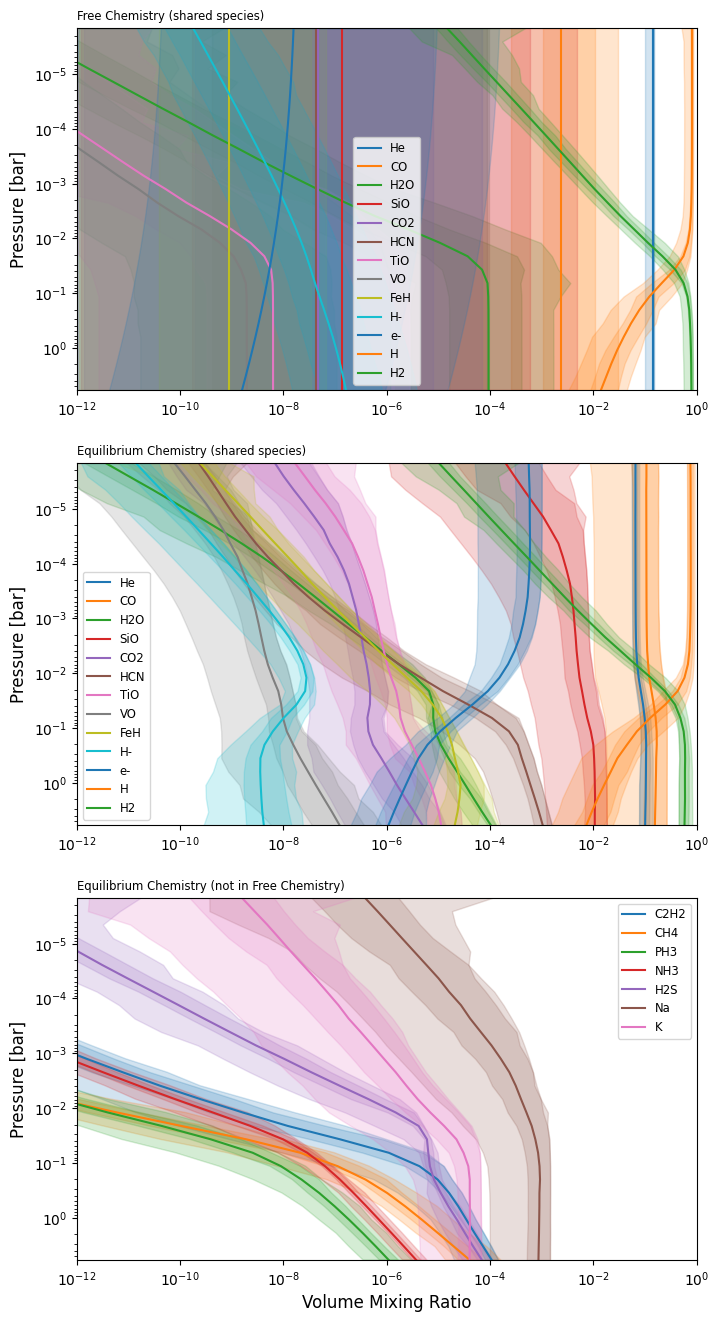

In [41]:
fig, ax = plt.subplots(3, 1, sharey=True, figsize=(8, 16))

for specie in profile_stats:
    if specie in profile_stats_eq:
        plot_p_profile_sample(pressures, profile_stats[specie], ax=ax[0], label=specie)
        plot_p_profile_sample(pressures, profile_stats_eq[specie], ax=ax[1], label=specie)
        
for specie in species_plt:
    if specie not in profile_stats:
        plot_p_profile_sample(pressures, profile_stats_eq[specie], ax=ax[2], label=specie)
        
        
ax[0].set_title('Free Chemistry (shared species)', loc='left', fontsize='small')
ax[1].set_title('Equilibrium Chemistry (shared species)', loc='left', fontsize='small')
ax[2].set_title('Equilibrium Chemistry (not in Free Chemistry)', loc='left', fontsize='small')

for ax_i in ax:
    ax_i.set_xscale('log')
    ax_i.set_xlim(1e-12, 1e0)
    ax_i.legend(fontsize='small')
    ax_i.set_ylabel('Pressure [bar]', fontsize='large')
    
ax[2].set_xlabel('Volume Mixing Ratio', fontsize='large')

In [42]:
from starships.plotting_fcts import _get_fig_and_ax_inputs, _get_idx_in_range, colorsDict, defaultColorsOrder

def plot_profile_combined(pressures, stats_list, p_range=(1e-6, 1e2), stats_keys=('1-sig', '2-sig'),
                          fig=None, ax=None, tight_range=True, colorsOrder=None):


    # Make sure there is a pressure array for each stats
    n_profiles = len(stats_list)
    if len(pressures) != n_profiles:
        pressures = [pressures for _ in range(n_profiles)]
    # Rename
    pressure_list = pressures
    
    if p_range is None:
        p_range = (np.min(pressure_list), np.max(pressure_list))
    
    # Use default color order from pyGTC
    if colorsOrder is None:
        colorsOrder = list(defaultColorsOrder[:n_profiles])

    # Get pressure index
    pressure_idx_list = [_get_idx_in_range(press, p_range) for press in pressure_list]

    
    # Plot starts here

    # Init figure and axes if needed
    fig, ax = _get_fig_and_ax_inputs(fig, ax)

    # Get colors and assign for each statistic in sample_stats (so each key)
    color_region = [dict() for _ in range(n_profiles)]
    # and assign for each statistic in sample_stats (so each key)
    for idx_pro, cs in enumerate(colorsOrder):
        stats = stats_list[idx_pro]
        for idx_stat, key in enumerate(stats_keys):
            try:
                color_region[idx_pro][key] = colorsDict[cs][idx_stat]
            except IndexError:
                raise IndexError(f"To many satistics to plot for available colors (length = {len(defaultColorsOrder)})")

    handles_for_legend = []
    for idx_pro in reversed(range(n_profiles)):
        stats = stats_list[idx_pro]
        color_pro = color_region[idx_pro]
        pressures = pressure_list[idx_pro]
        idx_p = pressure_idx_list[idx_pro]
        for key in reversed(stats_keys):
            x1, x2 = stats[key]
            handles = ax.fill_betweenx(pressures[idx_p], x1[idx_p], x2[idx_p], color=color_pro[key])
        handles_for_legend.append(handles)

    for idx_pro in reversed(range(1, n_profiles)):
        stats = stats_list[idx_pro]
        color_pro = color_region[idx_pro]
        pressures = pressure_list[idx_pro]
        idx_p = pressure_idx_list[idx_pro]
        for key in reversed(stats_keys):
            x1, x2 = stats[key]
            ax.plot(x1[idx_p], pressures[idx_p], '-', color=color_pro[key])
            ax.plot(x2[idx_p], pressures[idx_p], '-', color=color_pro[key])

    if tight_range:
        all_p = [pressures[idx_p] for pressures, idx_p in zip(pressure_list, pressure_idx_list)]
        ax.set_ylim(np.min(all_p), np.max(all_p))

    ax.set_yscale('log')    

    ylim = ax.get_ylim()
    if ylim[-1] > ylim[0]:
        ax.invert_yaxis()

    ax.set_ylabel('Pressure [bar]', fontsize=16)
    
    return fig, ax, list(reversed(handles_for_legend))

In [45]:
%matplotlib inline

<IPython.core.display.Javascript object>


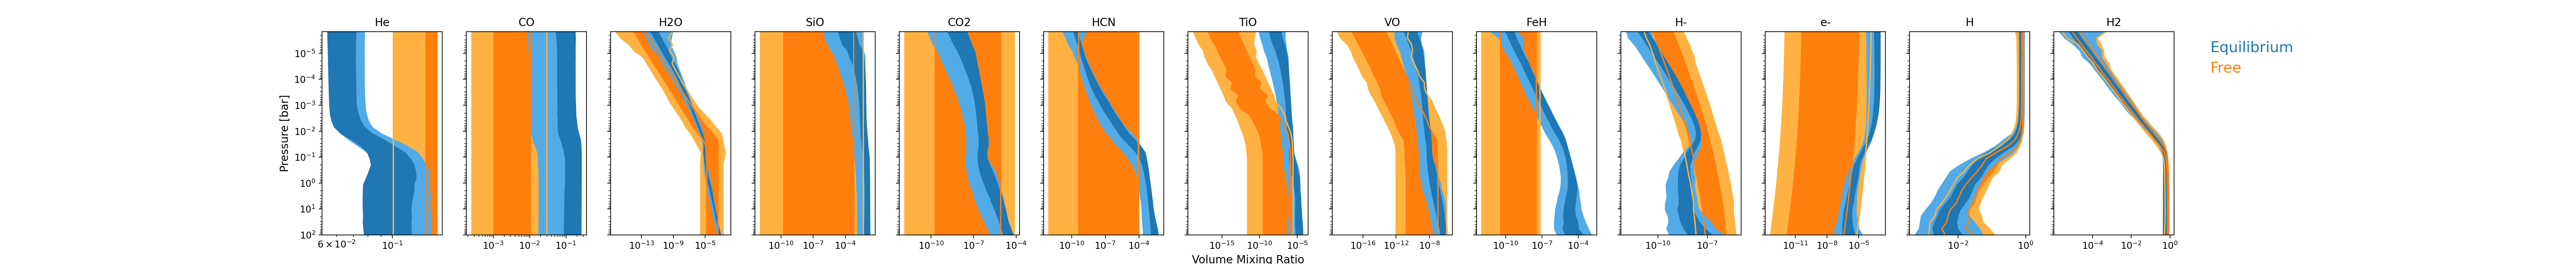

Text(0.5, 0, 'Volume Mixing Ratio')

In [44]:
species_compared = None #['CO']

if species_compared is None:
    species_compared = [specie for specie in profile_stats
                        if specie in profile_stats_eq]

n_species = len(species_compared)
fig, ax = plt.subplots(1, n_species + 1, sharey=True, figsize=(3 * n_species, 4))

for ax_i, specie in zip(ax, species_compared):
    _, _, handles = plot_profile_combined(pressures, [profile_stats_eq[specie], profile_stats[specie]], ax=ax_i)
    ax_i.set_xscale('log')
    ax_i.set_title(specie)
    ax_i.set_ylabel(None)

# Add a legend beside the panels
ax[-1].axis('off')
# Position of the text
xpos = 0.1
ypos = 0.9
d_ypos = -0.1
for handle, label in zip(handles, ['Equilibrium', 'Free']):
    color = handle.get_facecolor()[0]
    ax[-1].text(xpos, ypos, label, color=color, fontsize=16, transform=ax[-1].transAxes)
    ypos += d_ypos

ax[0].set_ylabel('Pressure [bar]', fontsize='large')
ax[n_species // 2].set_xlabel('Volume Mixing Ratio', fontsize='large')

# Show the model for specific parameters

## Generate/initialize the model

### Choose which parameters you want (best logL?, median?)
TIP: Look at the logL plot to see which one represents the best your results

In [33]:
params_set = ord_pos_sub  # Sub sample defined above
# params_set = ord_pos  # full sample

best_params = params_set[-1]  # Best logl
# best_params = params_set[len(params_set) // 2]  # Median

print(best_params)

[ -2.3479507   -4.40230224 320.1070873   19.57800829   0.57105812
  -1.42271593 146.9752757   -2.65340719   1.62281344 -14.73137873
   5.67910512   0.98071546   0.83851379]


In [34]:
# hand picked best params
# best_params = np.array([-1.,-4.5, 600, -5.8, 0.975, 0.63])

### Convert the parameters array to a dictionary of parameters

Note: `theta_regions` is a list of dictionnaries with all potential parameters that could be useful. You can edit it here if you  want before generating the model.

- Each dictionary represent a specific region on the planet (so usually just one region)

In [35]:
theta_regions = retrieval.unpack_theta(best_params)

In [36]:
# Print some values from region #1
_ = [print(key, theta_regions[0][key]) for key in retrieval.params_prior]

H2O 0.004487963337241807
CH4 3.960023490687408e-05
T_eq 320.1070873038997
T_int 19.5780082880471
tp_gamma 3.7244154514586483
kappa_IR 0.03778192420540531
kp 146.97527570370897
rv -2.65340718895576
p_cloud 41.95787107639489
gamma_scat -14.731378734194198
scat_factor 477644.8776647192
R_pl 7011330942.158324
cloud_fraction 0.8385137947237065


### Compute the spectrum (first time is slower due to initialization)
NOTE: We compute the spectrum with the 2 possible methods in petitRADTRANS (line-by-line and correlated-k) to make sure they are consistent. Correlated-k (c-k) is used for the fit only if the low-resolution observations (spectrophotometry or photometry) is not completely covered by the high-res spectrum.

In [37]:
wv_high, spec_high = retrieval.prepare_model_multi_reg(theta_regions, 'high')

INFO:starships.retrieval:Model not initialized for mode = high and range [0.9, 1.98]. Starting initialization...
INFO:starships.petitradtrans_utils:['H2O_pokazatel_main_iso', 'CH4_Hargreaves_main_iso']
/home/fgenest/starships_env/lib/python3.9/site-packages/petitRADTRANS/radtrans.py:100: FutureWarning: pRT_input_data_path was set by an environment variable. In a future update, the path to the petitRADTRANS input_data will be set within a .ini file that will be automatically generated into the user home directory (OS agnostic), inside a .petitradtrans directory
  warnings.warn(f"pRT_input_data_path was set by an environment variable. In a future update, the path to "


  Read line opacities of H2O_pokazatel_main_iso...
 Done.
  Read line opacities of CH4_Hargreaves_main_iso...
 Done.

  Read CIA opacities for H2-H2...


INFO:starships.petitradtrans_utils:Generating atmosphere with pressures from 100.0 to 1e-10
INFO:starships.petitradtrans_utils:You are not getting the individual contributions of the species
INFO:starships.retrieval:Saving values in `linelist_names`.
INFO:starships.retrieval:Star spectrum not initialized for mode = high. Starting initialization...
INFO:starships.retrieval:No stellar spectrum provided. A blackbody at Teff will be used.


  Read CIA opacities for H2-He...
Done.



In [38]:
wv_low, spec_low = retrieval.prepare_model_multi_reg(theta_regions, 'low')

INFO:starships.retrieval:Model not initialized for mode = low and range [0.9, 4.156887500000001]. Starting initialization...
INFO:starships.petitradtrans_utils:['H2O_HITEMP', 'CH4']


  Read line opacities of H2O_HITEMP...
 Done.
  Read line opacities of CH4...
 Done.

  Read CIA opacities for H2-H2...


INFO:starships.petitradtrans_utils:Generating atmosphere with pressures from 100.0 to 1e-10
INFO:starships.petitradtrans_utils:You are not getting the individual contributions of the species
INFO:starships.retrieval:Saving values in `linelist_names`.
INFO:starships.retrieval:Star spectrum not initialized for mode = low. Starting initialization...
INFO:starships.retrieval:No stellar spectrum provided. A blackbody at Teff will be used.


  Read CIA opacities for H2-He...
Done.



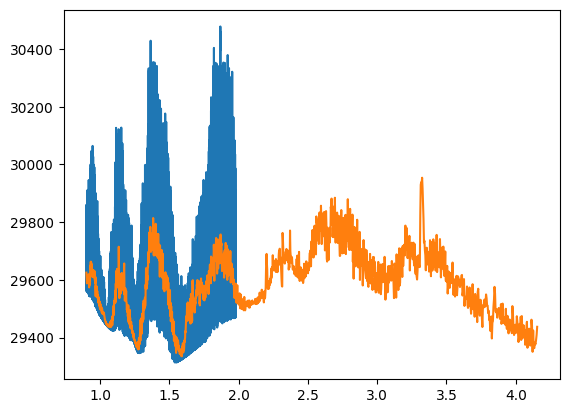

In [39]:
plt.plot(wv_high, spec_high*1e6)
plt.plot(wv_low, spec_low*1e6)

#### You can save the spectrum if you want to use it for other purpose.

In [37]:
save_spectrum = False
dir_spectra = Path.home() / Path('VSCodeProjects/starships_analysis/WASP-33b/Spectra')
file_stem = 'take3_HRR_modif_disso_31254924'
# file_stem = retrieval.walker_file_out.stem.split('walker_steps_')[-1]

In [38]:
if save_spectrum:
    filename = f'{file_stem}_all.npz'
    print('Saving', filename)
    np.savez(dir_spectra / filename, wave=wv_high, spec=spec_high)

### Show the spectrum for each individual specie (line opacity)
(Again can be useful to perform cross-correlations for example)

In [34]:
%matplotlib inline

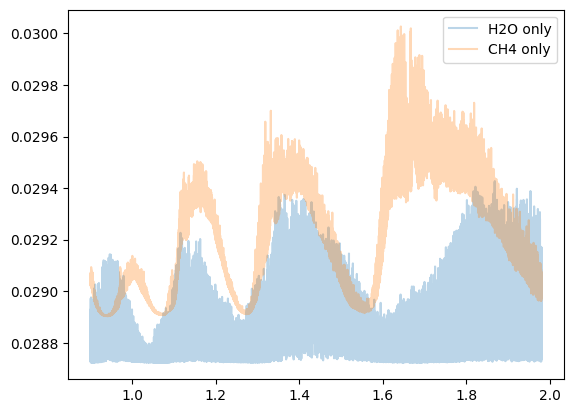

In [39]:
dir_spectra = Path.home() / Path('VSCodeProjects/starships_analysis/WASP-33b/Spectra')

for single_mol in retrieval.line_opacities:
    
    # Copy input dict
    theta_reg_single = [dict(theta_dict) for theta_dict in theta_regions]
    
    # Set all other linelists to zero (10^-99 to avoid division by zero)
    for theta_dict in theta_reg_single:
        for mol in retrieval.line_opacities:
            if mol != single_mol:
                theta_dict[mol] = 1e-99
    
    wv_high, spec_high = retrieval.prepare_model_multi_reg(theta_reg_single, 'high')
    plt.plot(wv_high, spec_high, label=f'{single_mol} only', alpha=0.3)
    
    if save_spectrum:
        dir_spectra.mkdir(exist_ok=True)
        filename = f'{file_stem}_{single_mol}_only.npz'
        print('Saving spectrum to:', filename)
        np.savez(dir_spectra/filename, wave=wv_high, spec=spec_high)

plt.legend()

## Quick comparison with spectrophotometric data
All the data available in the yaml file is plotted, but it may not have been included in the fit.
Ex: if you were using HRR mode.

In [40]:
from starships.plotting_fcts import get_plot_limits_from_data

In [41]:
# Get model spectra
wv_high, spec_high = retrieval.prepare_model_multi_reg(theta_regions, 'high')
wv_low, spec_low = retrieval.prepare_model_multi_reg(theta_regions, 'low')

# Make synthetic data for all low-res instruments
synt_data_dict = ru.get_syntetic_data_low_res(wv_low, spec_low, wv_high, spec_high, retrieval_obj=retrieval)

In [42]:
%matplotlib inline

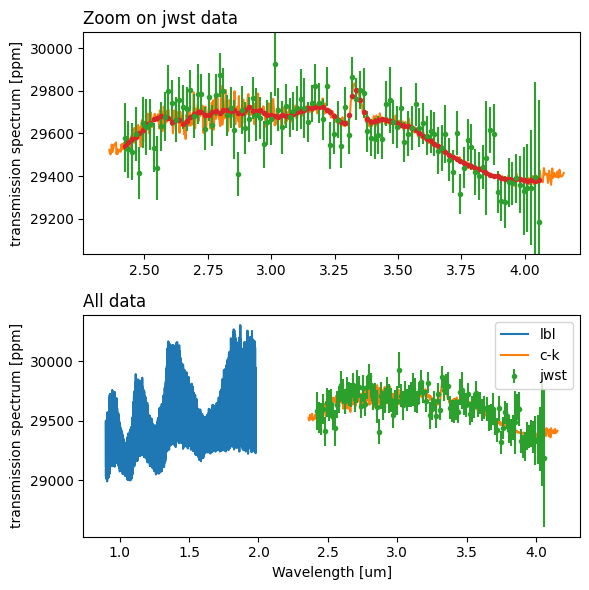

In [38]:
n_subplots = len(retrieval.spectrophotometric_data) + 1
fig, ax = plt.subplots(n_subplots, 1, figsize=(6, 3*n_subplots))

jwst_offset = 0

# Plot the model in each panel and set labels
for ax_i in ax:
    ax_i.plot(wv_high, spec_high * 1e6)#, label='lbl')
    ax_i.plot(wv_low, spec_low * 1e6)#, label="c-k")
    ax_i.set_ylabel(f"{retrieval.kind_trans} spectrum [ppm]")

# Make one panel per spectrophotmetric instrument name
for i_instru, (instru_name, infos) in enumerate(retrieval.spectrophotometric_data.items()):
    
    x_plot, y_plot, yerr = infos['wave'], infos['data'], infos['err']
    y_plot = y_plot * 1e6 + jwst_offset # in ppm
    yerr = yerr * 1e6  # in ppm
    
    # Force the plot limits around the low-res data
    xlim = get_plot_limits_from_data(x_plot)
    ylim = get_plot_limits_from_data(y_plot, pad=0.2)
    
    # Plots
    ax[i_instru].errorbar(x_plot, y_plot, yerr=yerr, fmt=".", label=instru_name)
    ax[i_instru].plot(x_plot, synt_data_dict[instru_name]*1e6, '.', label='Model binned')
    ax[i_instru].set_xlim(xlim)
    ax[i_instru].set_ylim(ylim)
    
    # Also plot in the last panel
    ax[-1].errorbar(x_plot, y_plot, yerr=yerr, fmt=".", label=instru_name)
    
    # Labels
    ax[i_instru].set_title(f"Zoom on {instru_name} data", loc='left')
    ax[i_instru].legend()


# Put everything in the last panel
for instru_name, infos in retrieval.photometric_data.items():
    
    x_plot, y_plot, yerr, x_limits = (infos[key] for key in ['wave', 'data', 'err', 'wv_coverages'])
    y_plot = y_plot * 1e6 # in ppm
    yerr = yerr * 1e6  # in ppm

    xerr = np.abs(np.transpose(x_limits) - x_plot)
    ax[-1].errorbar(x_plot, y_plot, yerr=yerr, xerr=xerr, fmt=".", label=instru_name)
    ax[-1].plot(x_plot, synt_data_dict[instru_name]*1e6, '.', label=f'Synt data ({instru_name})')


ax[-1].set_title(f"All data", loc='left')
ax[-1].set_xlabel("Wavelength [um]")
ax[-1].legend()
plt.tight_layout()

# path_fig = Path.home() / 'nirps/retrievals/plots/WASP-80b'
path_fig = Path.home() / 'nirps/figures/WASP-80b/CRAQ_2025'
plt.savefig(path_fig / f'{walker_file.name[:-3]}_jwst_model_comparison.pdf')

## Isolate the contribution of each species

In [81]:
specie_list = retrieval.line_opacities #['H2O', 'TiO', 'VO', 'FeH', 'OH', 'CO', 'H-']
wv, spec_dict = ru.get_contribution(specie_list, retrieval, theta_regions, mode='low')

(2.4, 4.2)

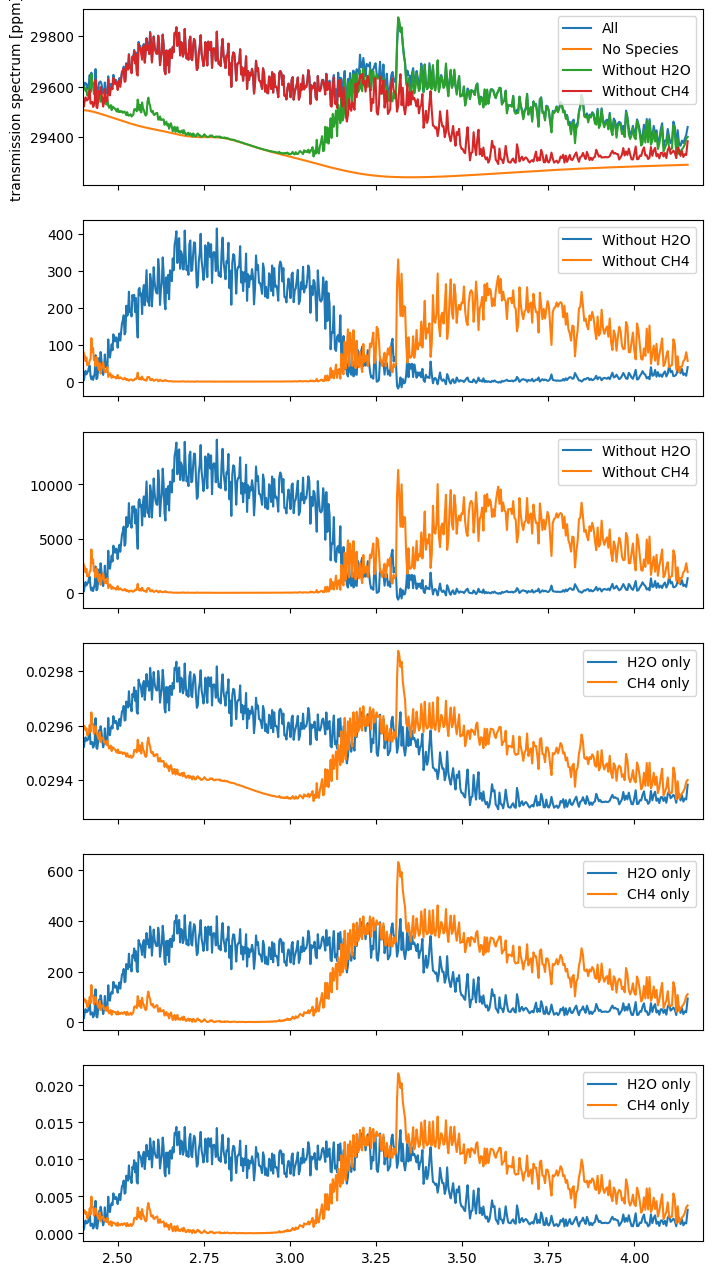

In [82]:
fig, ax = plt.subplots(6, 1 ,sharex=True, figsize=(8, 16))

for key, spec in spec_dict.items():
    if 'only' in key:
        ax[3].plot(wv, spec, label=key)
        spec = spec - spec_dict['No Species']
        ax[4].plot(wv, spec * 1e6, label=key)
        
        spec = spec / spec_dict['No Species']
        ax[5].plot(wv, spec, label=key)
    else:
        ax[0].plot(wv, spec * 1e6, label=key)
        if 'Without' in key:
            spec = spec_dict['All'] - spec
            ax[1].plot(wv, spec * 1e6, label=key)
            spec = spec / spec_dict['No Species']
            ax[2].plot(wv, spec * 1e6, label=key)
    
ax[0].set_ylabel(f"{retrieval.kind_trans} spectrum [ppm]")
# ax[3].set_ylabel('Difference (Specie - No Species) [ppm]')
# ax[4].set_ylabel('Relative to continuum (difference / No Specie)')

for ax_i in ax:
    ax_i.legend()

ax[1].set_xlim(2.4, 4.2)

In [92]:
specie_list = [['Fe','H2O', 'OH', 'H-'], ['Fe','H2O', 'H-'], ['Fe','OH', 'H-'], ['OH','H2O', 'H-']]
wv, spec_dict = ru.get_contribution(specie_list, retrieval, theta_regions, mode='high')

In [93]:
%matplotlib inline

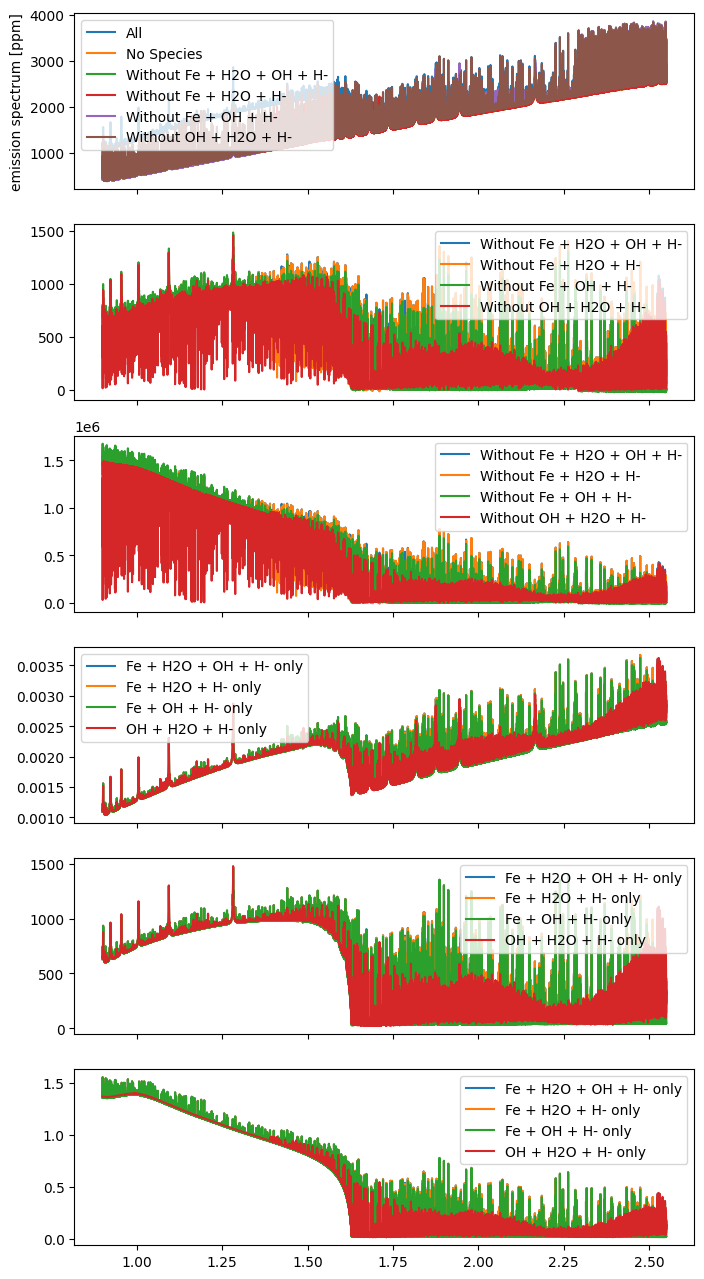

In [94]:
fig, ax = plt.subplots(6, 1 ,sharex=True, figsize=(8, 16))

for key, spec in spec_dict.items():
    if 'only' in key:
        ax[3].plot(wv, spec, label=key)
        spec = spec - spec_dict['No Species']
        ax[4].plot(wv, spec * 1e6, label=key)
        
        spec = spec / spec_dict['No Species']
        ax[5].plot(wv, spec, label=key)
    else:
        ax[0].plot(wv, spec * 1e6, label=key)
        if 'Without' in key:
            spec = spec_dict['All'] - spec
            ax[1].plot(wv, spec * 1e6, label=key)
            spec = spec / spec_dict['No Species']
            ax[2].plot(wv, spec * 1e6, label=key)
    
ax[0].set_ylabel(f"{retrieval.kind_trans} spectrum [ppm]")
# ax[3].set_ylabel('Difference (Specie - No Species) [ppm]')
# ax[4].set_ylabel('Relative to continuum (difference / No Specie)')

for ax_i in ax:
    ax_i.legend()

# ax[1].set_xlim(0.8, 2.)

In [98]:
for key, spec in spec_dict.items():

    if 'only' in key:

        if save_spectrum:
            dir_spectra.mkdir(exist_ok=True)
            # Remove + and spaces
            extension = key.replace('+', '').split()
            extension = '_'.join(extension)
            filename = f'{file_stem}_{extension}.npz'
            print('Saving spectrum to:', filename)
            np.savez(dir_spectra/filename, wave=wv, spec=spec)

Saving spectrum to: take3_HRR_modif_disso_31254924_Fe_H2O_OH_H-_only.npz
Saving spectrum to: take3_HRR_modif_disso_31254924_Fe_H2O_H-_only.npz
Saving spectrum to: take3_HRR_modif_disso_31254924_Fe_OH_H-_only.npz
Saving spectrum to: take3_HRR_modif_disso_31254924_OH_H2O_H-_only.npz


## Compare line opacities (low VS high)
**This is a good check to make when doing Joint Retrievals (JR)**
(but it generating the high res spectra can take a lot of time, so don't do this everytime)

In [52]:
specie_list = [[mol, 'H-'] for mol in retrieval.line_opacities]
wv_high, spec_dict_high = ru.get_contribution(specie_list, retrieval, theta_regions, mode='high')
wv_low, spec_dict_low = ru.get_contribution(specie_list, retrieval, theta_regions, mode='low')

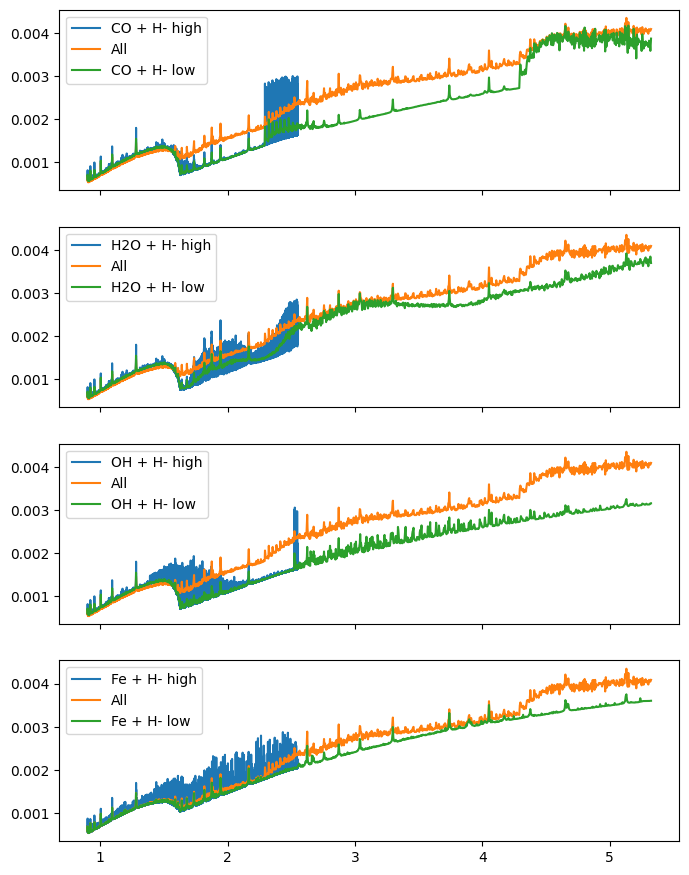

In [53]:
n_species = len(specie_list)

fig, ax = plt.subplots(n_species, 1 ,sharex=True, figsize=(8, n_species*2.7))

for idx, specie in enumerate(specie_list):
    specie_label = ' + '.join(specie)
    ax[idx].plot(wv_high, spec_dict_high[f'{specie_label} only'], label=f'{specie_label} high')
    
for idx, specie in enumerate(specie_list):
    specie_label = ' + '.join(specie)
    ax[idx].plot(wv_low, spec_dict_low['All'], label='All')
    ax[idx].plot(wv_low, spec_dict_low[f'{specie_label} only'], label=f'{specie_label} low')
    ax[idx].legend()
